In [19]:
# %% SECTION 1: Packages import
import os
import numpy as np

# Import other packages as necessary
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV 
from scipy.optimize import least_squares


In [20]:
# %% SECTION 2: Helper functions
# Define functions if needed
# Bounds: [e_r, g_bar, tau_m, tau_h]
lower = np.array([-150, 0,    0.01, 0.01])
upper = np.array([ 150, 1,    1e3,  1e4 ])

rng = np.random.default_rng(0)   # fixed seed -> reproducible
n_starts = 20

def gate_model(tau, x_0,x_inf,dt):
    y = x_0 + (x_inf - x_0) * (1 - np.exp(-dt / tau))
    return y

#probably needs to be fixed, we need to make the gates opening dependent on voltage as well somehow
def get_current(e_r, g_bar, tau_m, tau_h, v, t): 
    m = np.zeros(len(v))
    h = np.zeros(len(v))

    m[0] = 0
    h[0] = 1

    for i in range(1, len(t)):
        dt = t[i] - t[i-1]
        v_prev = v[i-1]

        m[i] = gate_model(tau_m, m[i-1], 1, dt)
        h[i] = gate_model(tau_h, h[i-1], 0, dt)

    return g_bar * (v - e_r) * m * h

def compute_error(params, t, v, test_i):
    e_r, g_bar, tau_m, tau_h = params
    return get_current(e_r, g_bar, tau_m, tau_h, v, t) - test_i

def random_start():
    e_r   = rng.uniform(-100, 50)
    g_bar = 10 ** rng.uniform(-5, -1)    # log-uniform: spans orders of magnitude
    tau_m = 10 ** rng.uniform(-1, 2)
    tau_h = 10 ** rng.uniform(0, 3)
    return [e_r, g_bar, tau_m, tau_h]

In [21]:
# %% SECTION 3: Main function
def run_vclamp_model(folder: str, data: str = "CookLab1UnknownChannel.txt"):
    """
    Compute current from voltage-clamp input.

    Parameters
    ----------
    folder :
        Directory with input file for voltage-clamp model.
    data :
        Name of input file.
    # Please list any parameters added to the function.

    Returns
    -------
    np.ndarray
        Output current computed by the voltage-clamp model.
    """
    # %% SECTION 3-a: Load provided input data.
    # NO MODIFICATIONS: This section should be kept as is.
    data = np.loadtxt(os.path.join(folder, "CookLab1UnknownChannel.txt"))
    v = data[:, 1]

    # i has the same shape as array v, add code in the next section to fill it
    i = np.empty_like(v)

    # %% SECTION 3-b: Compute i [to be filled by students]
    t = data[:, 0]
    test_i = data[:, 2]
    
    # fit = least_squares(compute_error, args = (t, v, test_i), x0 = [-60, 10, 1, 1])
    fits = []
    for i in range(n_starts):
        x0 = random_start()
        fit = least_squares(compute_error, x0=x0, args=(t, v, test_i), bounds = (lower,upper))
        fits.append(fit)
        print(f"start {i}: cost = {fit.cost:.4f}, success = {fit.success}, params = {fit.x}")

    best = min(fits, key=lambda f: f.cost)
    print("Best parameters:", best.x) 
    
    i = get_current(*best.x, v, t)

    ss_res = np.sum((test_i - i) ** 2)
    ss_tot = np.sum((test_i - np.mean(test_i)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    print(f"R-squared: {r_squared:.4f}")
    
    plt.figure()

    plt.subplot(2, 1, 1)
    plt.grid(True)
    plt.plot(t, v, linewidth=2)
    plt.axis("tight")
    plt.ylabel("V step (mV)")

    plt.subplot(2, 1, 2)
    plt.grid(True)
    plt.plot(t, test_i, label="Measured current")
    plt.plot(t, i, label="Model current")
    plt.xlabel("Time (msec)")
    plt.ylabel("Current (mA)")
    plt.legend()

    # %% SECTION 3-c: Assert validity of output and return it.
    # NO MODIFICATIONS: This section should be kept as is.
    assert len(i.shape) == 1, "Currrent array should be 1-dimensional"
    return i

start 0: cost = 0.1601, success = True, params = [-7.26218114e+00  5.39581439e-04  7.44407214e-02  1.00000000e+04]
start 1: cost = 0.1298, success = True, params = [-8.95324499e+00  6.23452934e-04  6.22485767e+01  1.00000000e+04]
start 2: cost = 0.1298, success = True, params = [-8.95324612e+00  6.23452960e-04  6.22485960e+01  1.00000000e+04]
start 3: cost = 0.1298, success = True, params = [-8.95324381e+00  6.23452917e-04  6.22485694e+01  1.00000000e+04]
start 4: cost = 0.1601, success = True, params = [-7.26218547e+00  5.39581419e-04  7.42894460e-02  1.00000000e+04]
start 5: cost = 0.1298, success = True, params = [-8.95324892e+00  6.23453013e-04  6.22486303e+01  1.00000000e+04]
start 6: cost = 0.1298, success = True, params = [-8.95324381e+00  6.23452923e-04  6.22485776e+01  1.00000000e+04]
start 7: cost = 0.1298, success = True, params = [-8.95324595e+00  6.23452957e-04  6.22485941e+01  1.00000000e+04]
start 8: cost = 0.1298, success = True, params = [-8.95324456e+00  6.23452928e-0

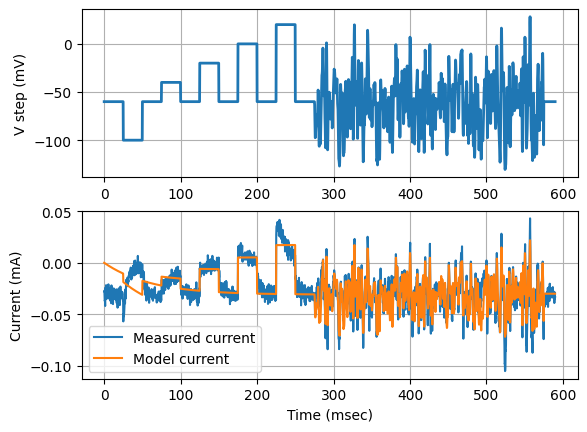

In [22]:
# %% SECTION 4: Function calls
if __name__ == "__main__":
    # Replace this with the path to the folder where provided input .txt file is!
    folder = "data"

    # Run function on the voltage-clamp data
    i = run_vclamp_model(folder)